[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Quantitative-Research-Methods/blob/main/Lab_Notebooks/chapter_04_lab.ipynb)

*This notebook runs on Colab as-is. The badge link above and the `GITHUB_RAW` line in the setup cell already point to this repository, so everything installs and loads automatically.*

# Chapter 4 — Classification
## Lab: logistic regression, LDA, QDA, naive Bayes, ROC, Poisson

**Course:** Quantitative Research Methods  
**Instructor:** Prof. Dr. Christoph Weisser, HSBI  
**Source:** James, Witten, Hastie, Tibshirani & Taylor (2023), *An Introduction to Statistical Learning, with Applications in Python*, Springer. Companion code at [statlearning.com](https://www.statlearning.com).


**Goal of this lab.** Fit five different classifiers on the Default and Smarket data, compare them via confusion matrices and ROC curves, and run a Poisson regression on Bikeshare.


## Setup

Run this cell once. The `ISLP` package can be installed with `pip install ISLP`. As an alternative, the same data sets are available as CSVs in the workspace's `ALL CSV FILES - 2nd Edition` folder.


> **Google Colab:** this notebook also runs on Colab out of the box — the setup cell below installs any missing packages and (once the repo is on GitHub and `GITHUB_RAW` is set) downloads the data automatically.



In [1]:
# --- Setup: runs locally AND on Google Colab --------------------------------
import importlib.util, os, subprocess, sys

IN_COLAB = 'google.colab' in sys.modules

def _ensure(pkg, import_name=None):
    """pip-install pkg (quietly) if its import is missing."""
    if importlib.util.find_spec(import_name or pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

if IN_COLAB:  # Colab ships numpy/pandas/sklearn/statsmodels; add course extras
    for _pkg, _imp in [('ISLP', 'ISLP')]:
        _ensure(_pkg, _imp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.dpi'] = 110

try:
    from ISLP import load_data
    HAVE_ISLP = True
except ImportError:
    HAVE_ISLP = False
    print('ISLP not installed; using CSV / URL fallbacks.')

# Local CSV location (repo layout first, then legacy paths, then a data/ cache).
_CANDIDATES = ['../ALL CSV FILES - 2nd Edition',
               'ALL CSV FILES - 2nd Edition',
               '../../ALL CSV FILES - 2nd Edition', 'data']
CSV = next((p for p in _CANDIDATES if os.path.isdir(p)), 'data')

# GITHUB_RAW lets a fresh Colab runtime fetch any
# CSV that is neither in ISLP nor already local (spaces in the folder -> %20).
GITHUB_RAW = ('https://raw.githubusercontent.com/ChrisW09/Quantitative-Research-Methods/main/'
              'ALL%20CSV%20FILES%20-%202nd%20Edition')

# The three datasets NOT in the ISLP package -> load from the book's official
# site so the notebook works on a fresh Colab even before the repo is published.
KNOWN_URLS = {
    'Advertising': 'https://www.statlearning.com/s/Advertising.csv',
    'Heart':       'https://www.statlearning.com/s/Heart.csv',
    'Income1':     'https://www.statlearning.com/s/Income1.csv',
    'Income2':     'https://www.statlearning.com/s/Income2.csv',
}

def load(name, **read_csv_kwargs):
    """Load a course dataset. Order: ISLP package -> R datasets -> local CSV
    -> official book URL -> your GitHub repo. Works locally and on Colab."""
    if HAVE_ISLP:
        try:
            return load_data(name)
        except Exception:
            pass
    if name == 'USArrests':                       # classic R dataset, not in ISLP
        try:
            import statsmodels.api as sm
            return sm.datasets.get_rdataset('USArrests', 'datasets').data
        except Exception:
            pass
    path = f'{CSV}/{name}.csv'
    if os.path.exists(path):                      # running from the repo (local)
        return pd.read_csv(path, **read_csv_kwargs)
    remotes = ([KNOWN_URLS[name]] if name in KNOWN_URLS else []) + [f'{GITHUB_RAW}/{name}.csv']
    for url in remotes:                           # fresh Colab: stream over https
        try:
            return pd.read_csv(url, **read_csv_kwargs)
        except Exception:
            continue
    raise FileNotFoundError(
        f"Could not load {name!r}. Put the CSV in '{CSV}/' or check your connection for the GITHUB_RAW fallback.")

## 1. Logistic regression


In [2]:
import statsmodels.api as sm
Default = load('Default')
y = (Default['default'] == 'Yes').astype(int)
Default['student_d'] = (Default['student'] == 'Yes').astype(int)
X = sm.add_constant(Default[['balance', 'income', 'student_d']])
res = sm.GLM(y, X, family=sm.families.Binomial()).fit()
print(res.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                default   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9996
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -785.77
Date:                Sun, 19 Jul 2026   Deviance:                       1571.5
Time:                        14:31:49   Pearson chi2:                 7.00e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1262
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.8690      0.492    -22.079      0.0

Note that `student_d` flips sign once `balance` is held constant — the textbook's *student paradox*.


### Predicted probabilities


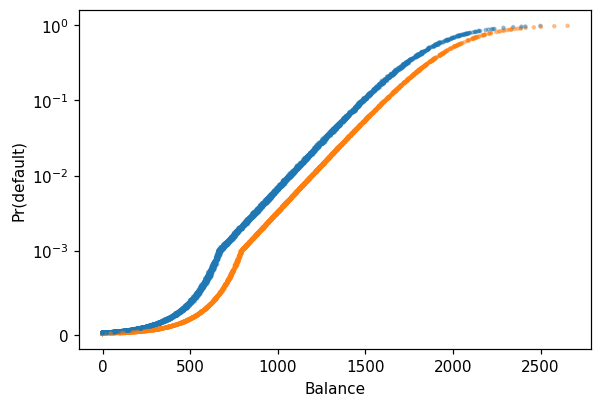

In [3]:
p = res.predict(X)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(Default['balance'], p, s=4, alpha=0.4,
            c=Default['student_d'].map({0: 'C0', 1: 'C1'}))
ax.set(xlabel='Balance', ylabel='Pr(default)')
ax.set_yscale('symlog', linthresh=1e-3); plt.show()


## 2. LDA, QDA, naive Bayes, KNN — head-to-head


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis as LDA,
    QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score

X = Default[['balance', 'income', 'student_d']].values
y = (Default['default'] == 'Yes').astype(int).values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)
scaler = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

models = {
    'logit': LogisticRegression(max_iter=2000),
    'LDA':   LDA(),
    'QDA':   QDA(),
    'NB':    GaussianNB(),
    'KNN5':  KNeighborsClassifier(n_neighbors=5),
}

for name, mdl in models.items():
    mdl.fit(Xtr_s, ytr)
    proba = mdl.predict_proba(Xte_s)[:, 1]
    print(f'{name:6s}  AUC = {roc_auc_score(yte, proba):.3f}')


logit   AUC = 0.946
LDA     AUC = 0.946
QDA     AUC = 0.946
NB      AUC = 0.935
KNN5    AUC = 0.811


### ROC curves


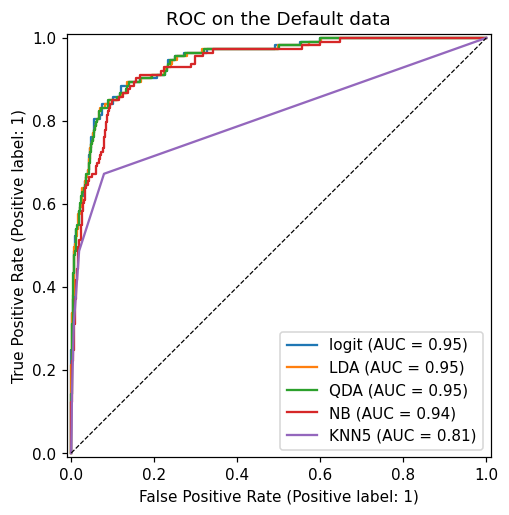

In [5]:
from sklearn.metrics import RocCurveDisplay
fig, ax = plt.subplots(figsize=(5, 5))
for name, mdl in models.items():
    RocCurveDisplay.from_estimator(mdl, Xte_s, yte, ax=ax, name=name)
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_title('ROC on the Default data'); plt.show()


## 3. Poisson regression on Bikeshare


In [6]:
Bike = load('Bikeshare')
Bike.columns


Index(['season', 'mnth', 'day', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
       'registered', 'bikers'],
      dtype='object')

In [7]:
X = sm.add_constant(Bike[['temp', 'hum', 'windspeed']])
pois = sm.GLM(Bike['bikers'], X, family=sm.families.Poisson()).fit()
print(pois.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                 bikers   No. Observations:                 8645
Model:                            GLM   Df Residuals:                     8641
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -4.0933e+05
Date:                Sun, 19 Jul 2026   Deviance:                   7.6563e+05
Time:                        14:31:50   Pearson chi2:                 7.96e+05
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.5665      0.005    948.324      0.0

Coefficients are on the log-rate scale: `exp(beta)` is the multiplicative effect on hourly ridership.


## Lecture exercises — worked Python solutions

Runnable, verified solutions to the three `[Python]`-tagged exercises in the Chapter 4 lecture deck. Each cell uses the `load()` helper from the **Setup** cell above (no hard-coded paths), and the reported numbers match the slide solutions.

### Extended Exercise 4.5 — Default: logistic regression, confusion matrix, ROC/AUC

Using the `Default` data: **(1)** fit a logistic regression of `default` on `balance`, `income` and a 0/1 `student` indicator; **(2)** build the confusion matrix at thresholds 0.5 and 0.2; **(3)** at each threshold report accuracy, sensitivity, specificity and precision; **(4)** plot the ROC curve and report the AUC.

   t    TN   FP   FN   TP    acc  sens  spec  prec
 0.5  9627   40  228  105  0.973 0.315 0.996 0.724
 0.2  9390  277  130  203  0.959 0.610 0.971 0.423
AUC = 0.95


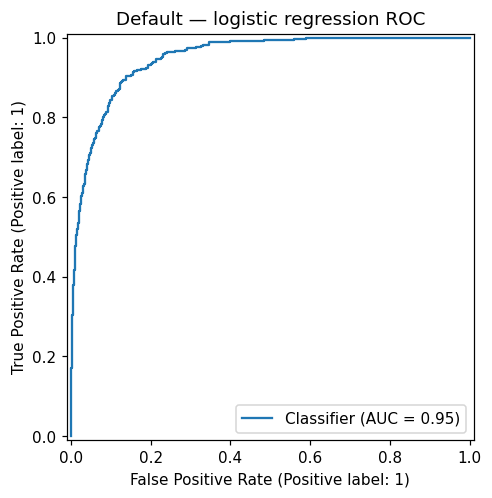

In [8]:
# Extended Exercise 4.5 — Default: logistic regression, confusion matrix, ROC/AUC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score, RocCurveDisplay

Default = load('Default')                                # setup-cell helper (ISLP -> CSV)
y = (Default['default'] == 'Yes').astype(int)            # encode response as 0/1
X = Default.assign(stud=(Default['student'] == 'Yes').astype(int)
                   )[['balance', 'income', 'stud']].values   # predictors incl. student dummy

clf   = LogisticRegression(max_iter=10000).fit(X, y)     # fit by (penalised) maximum likelihood
proba = clf.predict_proba(X)[:, 1]                        # predicted P(default = Yes) per customer

# metrics at two decision thresholds (sklearn orders cells as TN, FP, FN, TP)
print(f"{'t':>4} {'TN':>5} {'FP':>4} {'FN':>4} {'TP':>4}  {'acc':>5} {'sens':>5} {'spec':>5} {'prec':>5}")
for t in (0.5, 0.2):
    tn, fp, fn, tp = confusion_matrix(y, proba > t).ravel()
    sens, spec = tp/(tp+fn), tn/(tn+fp)                  # sensitivity, specificity
    prec, acc  = tp/(tp+fp), (tp+tn)/len(y)              # precision, accuracy
    print(f"{t:>4} {tn:>5} {fp:>4} {fn:>4} {tp:>4}  "
          f"{acc:>5.3f} {sens:>5.3f} {spec:>5.3f} {prec:>5.3f}")

print('AUC =', round(roc_auc_score(y, proba), 3))        # threshold-free ranking quality
RocCurveDisplay.from_predictions(y, proba)               # draw the ROC curve
plt.title('Default — logistic regression ROC'); plt.show()

# Expected output (matches slide Extended Exercise 4.5):
#     t    TN   FP   FN   TP    acc  sens  spec  prec
#   0.5  9627   40  228  105  0.973 0.315 0.996 0.724
#   0.2  9390  277  130  203  0.959 0.610 0.971 0.423
#   AUC = 0.95

At threshold **0.5** the model is accurate (97.3%) but has low **sensitivity** (0.315) — it misses about two-thirds of true defaulters, the *always-predict-No* trap on imbalanced data. Lowering the threshold to **0.2** nearly doubles sensitivity (0.610) at the cost of specificity (0.996 → 0.971) and precision (0.724 → 0.423): more false alarms. The **AUC** (0.95) is threshold-free — it measures ranking quality across *all* cutoffs, so it is unchanged by the threshold. Choose the operating point by the bank's relative cost of a missed defaulter (FN) versus a false alarm (FP).

### Exercise 4.10 — Logistic regression + confusion matrix in Python

Using the `Default` data: **(1)** fit logistic regression of `default` on `balance`, `income` and a 0/1 `student` indicator; **(2)** produce the confusion matrix at thresholds 0.5 and 0.2; **(3)** report the sensitivity at each threshold and interpret the trade-off. *(Same fitted model as Extended Exercise 4.5.)*

In [9]:
# Exercise 4.10 — confusion matrix and sensitivity at two thresholds.
# Reuses y and proba from the Extended Exercise 4.5 fit above (identical Default model).
for t in (0.5, 0.2):                                     # default and lowered cutoff
    tn, fp, fn, tp = confusion_matrix(y, proba > t).ravel()   # order: TN, FP, FN, TP
    sens = tp / (tp + fn)                                # sensitivity = TP / actual positives
    print(f't={t}: TN={tn} FP={fp} FN={fn} TP={tp}  sens={sens:.3f}')

# Expected output (reproducible slide numbers; identical to Extended Exercise 4.5):
#   t=0.5: TN=9627 FP=40  FN=228 TP=105  sens=0.315
#   t=0.2: TN=9390 FP=277 FN=130 TP=203  sens=0.610

t=0.5: TN=9627 FP=40 FN=228 TP=105  sens=0.315
t=0.2: TN=9390 FP=277 FN=130 TP=203  sens=0.610


At the default threshold **0.5** the model is accurate overall but low-sensitivity (0.315): it misses most true defaulters, exactly as LDA does on this data. Dropping the threshold to **0.2** roughly doubles sensitivity (0.610) by flagging more customers, at the cost of more false positives (FP 40 → 277, so lower specificity). The right threshold depends on the bank's relative cost of a missed defaulter versus a false alarm. `sklearn`'s `confusion_matrix` orders cells as [[TN, FP], [FN, TP]].

### Extended Exercise 4.6 — Predicting market direction out-of-sample

Using the `Weekly` data (weekly S&P 500 returns 1990–2010; `Direction` is Up/Down): **(1)** fit logistic regression of `Direction` on `Lag1`–`Lag5` and `Volume` on the full data — report in-sample accuracy and the confusion matrix; **(2)** an *honest* out-of-sample test — train on Year ≤ 2008, test on 2009–2010, using `Lag2` only — reporting test accuracy and confusion matrix for logistic regression **and** LDA; **(3)** compare with the naive *always predict Up* baseline.

In [10]:
# Extended Exercise 4.6 — market direction: in-sample vs honest out-of-sample
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, confusion_matrix

wk   = load('Weekly')                                    # setup-cell helper (ISLP -> CSV)
yw   = (wk['Direction'] == 'Up').astype(int)             # encode Up = 1, Down = 0
lags = ['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']

# (1) in-sample logistic regression on all predictors (optimistic: fit and score on all data)
full = LogisticRegression(max_iter=10000).fit(wk[lags], yw)
print('(1) in-sample acc:', round(full.score(wk[lags], yw), 3))
print('    confusion [[TN,FP],[FN,TP]]:')
print(confusion_matrix(yw, full.predict(wk[lags])))

# (2) honest split: train Year <= 2008, test 2009-2010, using Lag2 as the only predictor
tr, te = wk['Year'] <= 2008, wk['Year'] >= 2009          # boolean train/test masks
for nm, mdl in [('logit', LogisticRegression(max_iter=10000)), ('LDA', LDA())]:
    mdl.fit(wk.loc[tr, ['Lag2']], yw[tr])                # fit on <= 2008
    pred = mdl.predict(wk.loc[te, ['Lag2']])             # predict 2009-2010
    print(f'(2) {nm:5s}: acc={accuracy_score(yw[te], pred):.3f}  '
          f'TN FP FN TP = {confusion_matrix(yw[te], pred).ravel()}')

# (3) naive baseline: always predict 'Up'
print('(3) always-Up baseline acc:', round((yw[te] == 1).mean(), 3),
      f'(n_test = {int(te.sum())})')

# Expected output (matches slide Extended Exercise 4.6):
#   (1) in-sample acc: 0.561 ; confusion [[ 54 430],[ 48 557]]
#   (2) logit: acc=0.625  TN FP FN TP = [ 9 34  5 56]
#       LDA  : acc=0.625  TN FP FN TP = [ 9 34  5 56]
#   (3) always-Up baseline acc: 0.587  (n_test = 104)

(1) in-sample acc: 0.561
    confusion [[TN,FP],[FN,TP]]:
[[ 54 430]
 [ 48 557]]
(2) logit: acc=0.625  TN FP FN TP = [ 9 34  5 56]
(2) LDA  : acc=0.625  TN FP FN TP = [ 9 34  5 56]
(3) always-Up baseline acc: 0.587 (n_test = 104)


The full-data model reaches only **56.1%** and predicts *Up* almost always (430 + 557 of 1089 rows) — the apparent edge is mostly the market's upward drift, and it is optimistic because it is in-sample. Out-of-sample (2009–2010), logistic regression and LDA give the **identical** 62.5% and confusion matrix (they are near-identical linear classifiers): they catch 56/61 up-weeks (sensitivity 0.92) but only 9/43 down-weeks (specificity 0.21). The *always predict Up* baseline already scores 58.7%, so the models beat it only marginally. Weekly returns are close to a random walk — the lagged predictors carry almost no signal — which is why market-direction prediction is so hard once transaction costs are included.

## 4. Exercises
1. Tune the threshold on the logistic regression to maximise balanced accuracy on the test set.
2. Fit logistic regression on `Smarket` and report the classification rate on 2005 data only.
3. Compare AUCs after standardising vs. not standardising. Which models are sensitive?
4. Add an `hr` (hour) factor to the Bikeshare Poisson model and interpret the resulting coefficients.
